In [4]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-29 12:19:05.456083


# Create AnnData from Xenium output folders

**Pinned Environment:** [`envs/sc-spatial.yaml`](../.../envs/sc-spatial.yaml)

In [5]:
import sys
from pathlib import Path
import os
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import math

In [6]:
plt.rcParams["figure.dpi"] = 150

In [ ]:
#

## Set paths

In [22]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR
base_dir = BASE_DIR

data_input_folder = '/home/workspace/data/temp/DRG'
fig_dir = base_dir / "figures/qc"
h5ad_dir = base_dir / "data/h5ad/export_01/01a_raw/output_folder"
metadata_dir = base_dir / "metadata"

paths_to_create = [base_dir, fig_dir, h5ad_dir, metadata_dir]

for path in paths_to_create:
    path.mkdir(parents=True, exist_ok=True)

In [11]:
sample_id_mapping = {
    "output-XETG00123__0076900__TMA00315__20251219__223811": {
        "region": "TMA00315",
        "slide": "0076900",
    },
    "output-XETG00123__0076900__TMA00316__20251219__223811": {
        "region": "TMA00316",
        "slide": "0076900",
    },
    "output-XETG00123__0076901__TMA00317__20251219__223811": {
        "region": "TMA00317",
        "slide": "0076901",
    },
    "output-XETG00123__0076901__TMA00318__20251219__223811": {
        "region": "TMA00318",
        "slide": "0076901",
    },
}

## Functions

In [12]:
def h5_to_adata(directory, sample_id):
    # File names
    h5_file = os.path.join(directory, "cell_feature_matrix.h5")
    cells_file = os.path.join(directory, "cells.csv.gz")

    # h5 to adata
    adata = sc.read_10x_h5(filename=h5_file)

    # cells file
    df = pd.read_csv(cells_file, compression="gzip")

    # Set index
    df.set_index(adata.obs_names, inplace=True)
    adata.obs = df.copy()

    # x, y coordinates
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

    # Add sample metadata
    adata.obs["sample_id"] = sample_id

    return adata

## Create sample dictionary

In [13]:
directory_to_sample = {
    os.path.join(data_input_folder, subdir): f"{subdir}"
    for subdir in os.listdir(data_input_folder)
    if os.path.isdir(os.path.join(data_input_folder, subdir))
    if os.path.isdir(os.path.join(data_input_folder, subdir))
    and not subdir.startswith(".")  # Excludes hidden folders like .ipynb_checkpoints
}

print(directory_to_sample)

{'/home/workspace/data/temp/DRG/output-XETG00123__0076900__TMA00316__20251219__223811': 'output-XETG00123__0076900__TMA00316__20251219__223811', '/home/workspace/data/temp/DRG/output-XETG00123__0076900__TMA00315__20251219__223811': 'output-XETG00123__0076900__TMA00315__20251219__223811', '/home/workspace/data/temp/DRG/output-XETG00123__0076901__TMA00317__20251219__223811': 'output-XETG00123__0076901__TMA00317__20251219__223811', '/home/workspace/data/temp/DRG/output-XETG00123__0076901__TMA00318__20251219__223811': 'output-XETG00123__0076901__TMA00318__20251219__223811'}


## Create anndata

In [14]:
# Loop through each key-value pair in the dictionary
adata_list = []
for directory, output_id in directory_to_sample.items():
    print(f"Processing: {directory} -> Run ID: {output_id}")
    adata = h5_to_adata(directory, output_id)
    adata.obs["output_id"] = output_id
    adata_list.append(adata)

Processing: /home/workspace/data/temp/DRG/output-XETG00123__0076900__TMA00316__20251219__223811 -> Run ID: output-XETG00123__0076900__TMA00316__20251219__223811
Processing: /home/workspace/data/temp/DRG/output-XETG00123__0076900__TMA00315__20251219__223811 -> Run ID: output-XETG00123__0076900__TMA00315__20251219__223811
Processing: /home/workspace/data/temp/DRG/output-XETG00123__0076901__TMA00317__20251219__223811 -> Run ID: output-XETG00123__0076901__TMA00317__20251219__223811
Processing: /home/workspace/data/temp/DRG/output-XETG00123__0076901__TMA00318__20251219__223811 -> Run ID: output-XETG00123__0076901__TMA00318__20251219__223811


In [15]:
for adata in adata_list:
    adata.obs["sample_id"] = adata.obs["output_id"].map(
        lambda x: sample_id_mapping[x]["region"]
    )
    adata.obs["region_id"] = adata.obs["sample_id"]
    adata.obs["slide_id"] = adata.obs["output_id"].map(
        lambda x: sample_id_mapping[x]["slide"]
    )

    print(adata.obs[["output_id", "sample_id", "region_id", "slide_id"]].head(1))

                                                    output_id sample_id  \
aaaacmnk-1  output-XETG00123__0076900__TMA00316__20251219_...  TMA00316   

           region_id slide_id  
aaaacmnk-1  TMA00316  0076900  
                                                    output_id sample_id  \
aaabfmch-1  output-XETG00123__0076900__TMA00315__20251219_...  TMA00315   

           region_id slide_id  
aaabfmch-1  TMA00315  0076900  
                                                    output_id sample_id  \
aaabecpg-1  output-XETG00123__0076901__TMA00317__20251219_...  TMA00317   

           region_id slide_id  
aaabecpg-1  TMA00317  0076901  
                                                    output_id sample_id  \
aaagnhaj-1  output-XETG00123__0076901__TMA00318__20251219_...  TMA00318   

           region_id slide_id  
aaagnhaj-1  TMA00318  0076901  


## QC

In [16]:
adata_list

[AnnData object with n_obs × n_vars = 26319 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 25867 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 21723 × 480
     obs: 'cell_id', 'x_ce

In [17]:
adata_list = sorted(adata_list, key=lambda ad: ad.obs["sample_id"].iloc[0]) # ordered

#### Visualize QC metrics

TMA00315
25867 cells
TMA00316
26319 cells
TMA00317
21723 cells
TMA00318
22761 cells


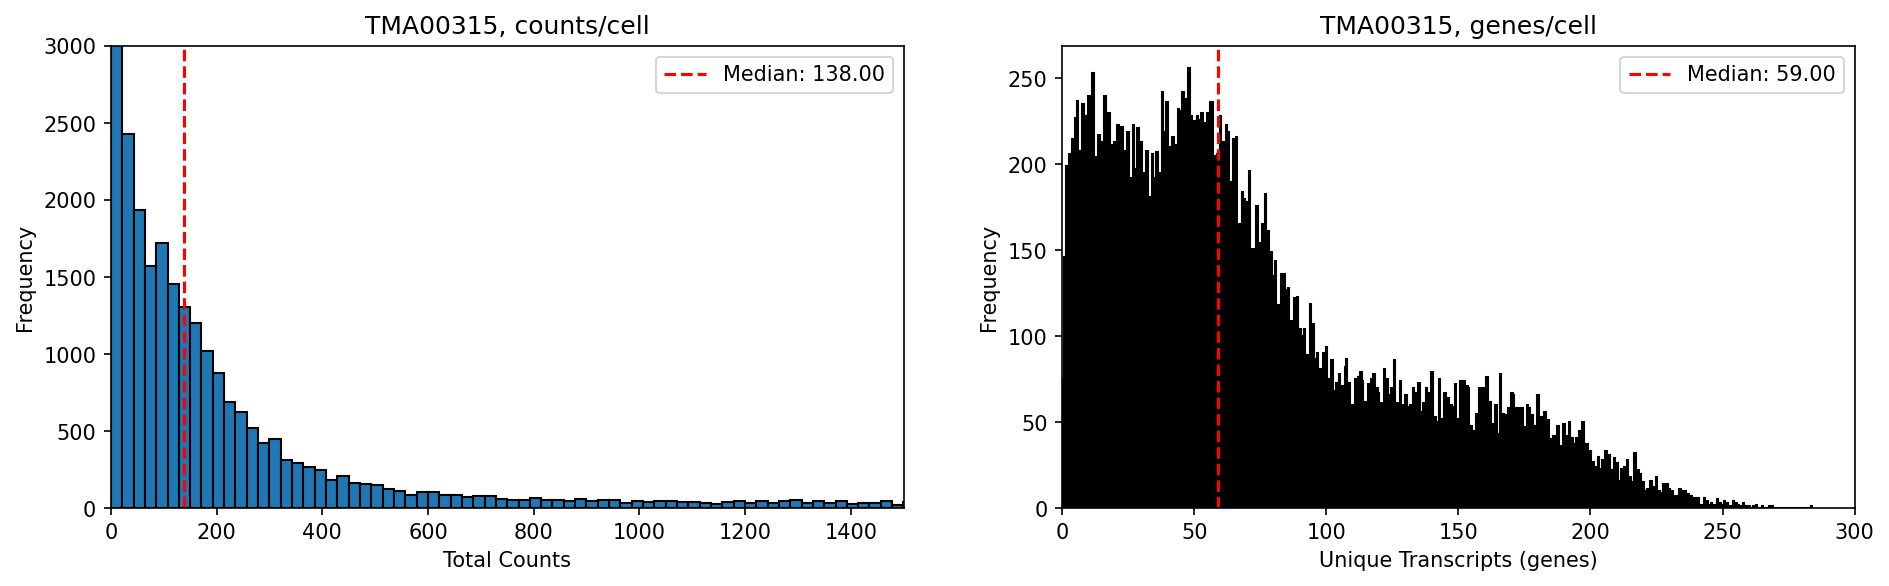

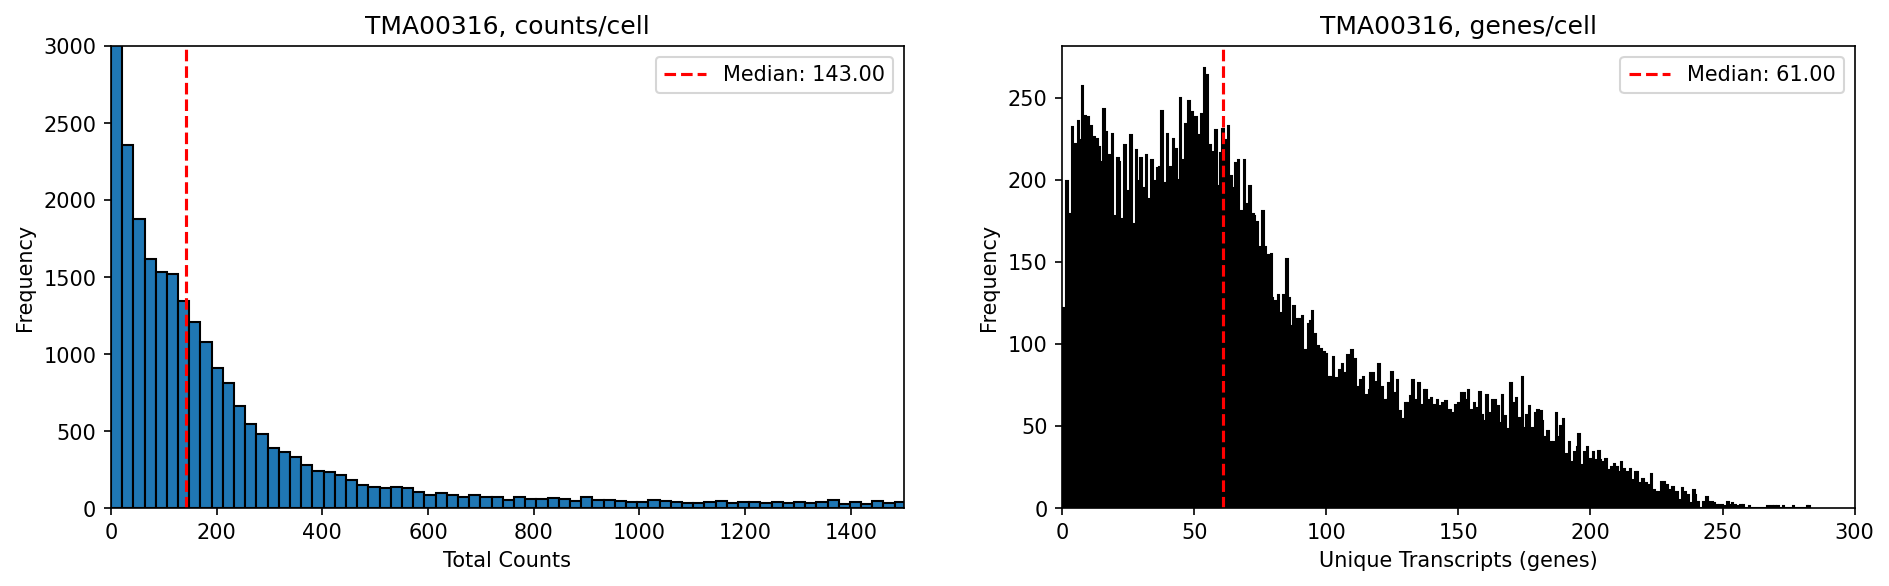

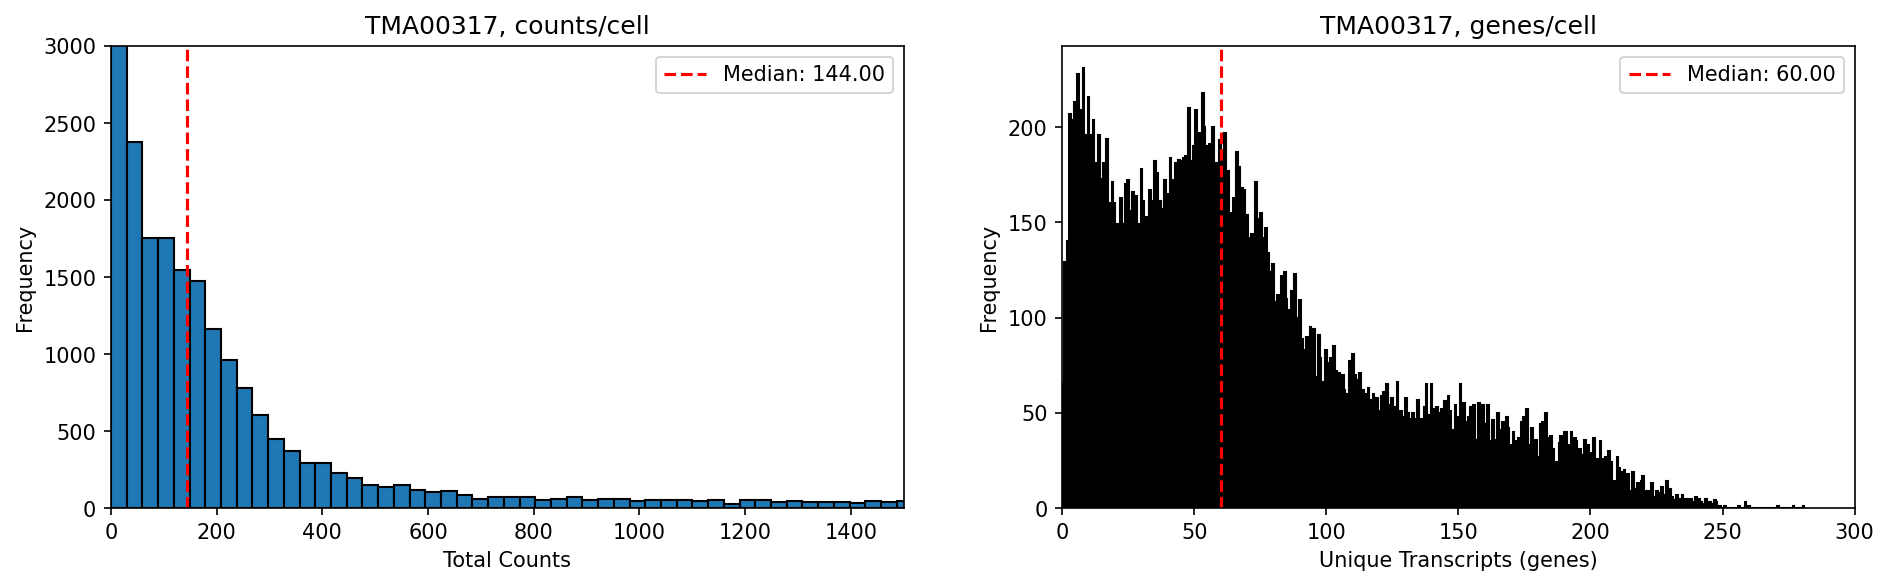

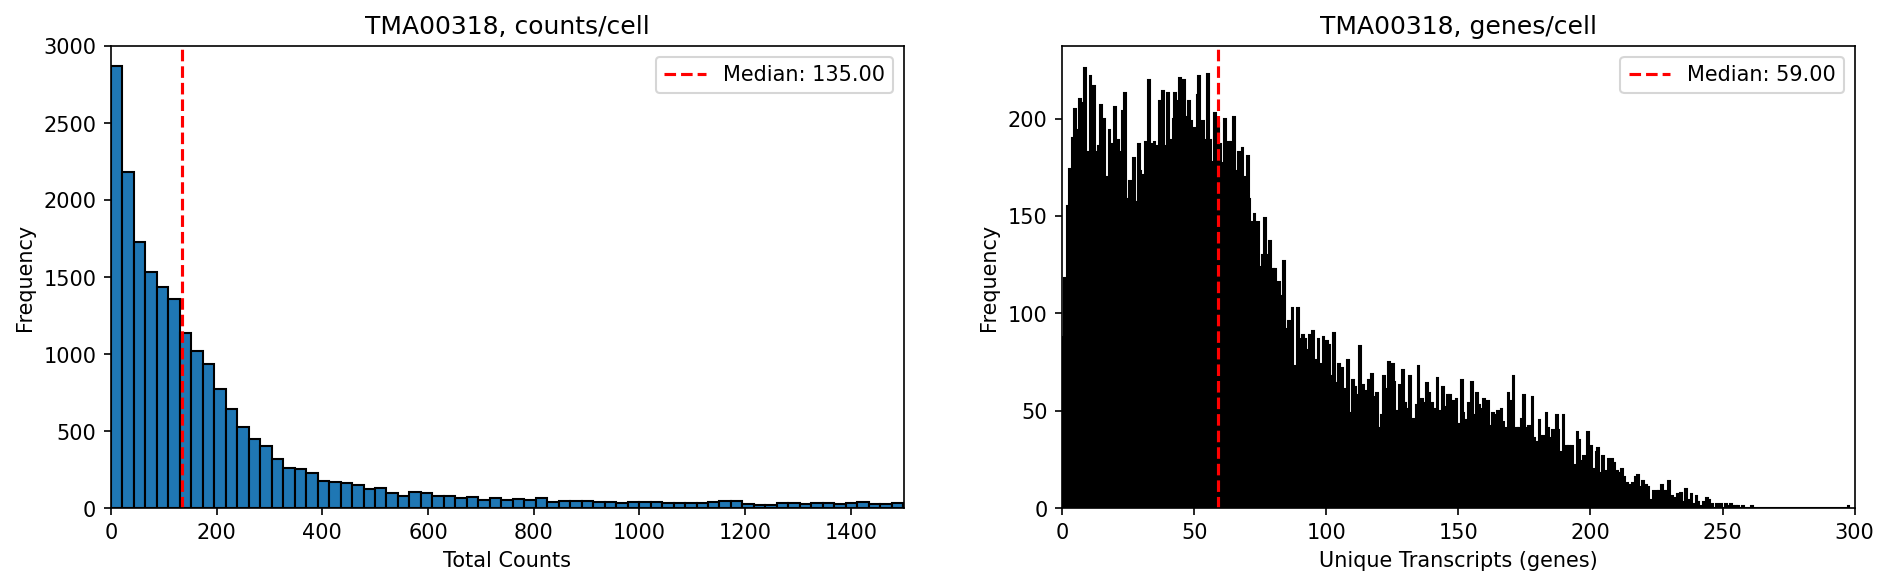

In [18]:
for adata in adata_list:
    sample_id = adata.obs["sample_id"].iloc[0]
    print(sample_id)

    # Calculate QC
    sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

    # Number of cells
    cell_num = adata.obs.shape[0]
    print(cell_num, "cells")

    # Visualize QC
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    # Plot the first histogram: Total Counts
    counts_median = adata.obs["total_counts"].median()
    axs[0].hist(
        adata.obs["total_counts"], bins=math.ceil(cell_num / 50), edgecolor="black"
    )
    axs[0].set_title(sample_id + ", " + "counts/cell")
    axs[0].set_xlim(0, 1500)
    axs[0].set_ylim(0, 3000)
    axs[0].set_xlabel("Total Counts")
    axs[0].set_ylabel("Frequency")
    axs[0].axvline(
        counts_median, color="red", linestyle="--", label=f"Median: {counts_median:.2f}"
    ) 
    axs[0].legend()

    # Plot the second histogram: Genes by Counts
    genes_median = adata.obs["n_genes_by_counts"].median()
    axs[1].hist(
        adata.obs["n_genes_by_counts"], bins=math.ceil(cell_num / 50), edgecolor="black"
    )
    axs[1].set_title(sample_id + ", " + "genes/cell")
    axs[1].set_xlim(0, 300)
    axs[1].set_xlabel("Unique Transcripts (genes)")
    axs[1].set_ylabel("Frequency")
    axs[1].axvline(
        genes_median, color="red", linestyle="--", label=f"Median: {genes_median:.2f}"
    ) 
    axs[1].legend()
    fig.savefig(os.path.join(fig_dir, sample_id + "_raw_QC.png"))

## Genes of interest

In [19]:
genes = adata.var
genes.head()

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
1500009L16Rik,ENSMUSG00000087651,Gene Expression,Unknown,1045,0.064145,0.062171,95.408813,1460.0,7.286876
6330403K07Rik,ENSMUSG00000018451,Gene Expression,Unknown,6369,3.927639,1.594860,72.017925,89397.0,11.400853
Abcb1a,ENSMUSG00000040584,Gene Expression,Unknown,4481,0.692896,0.526441,80.312816,15771.0,9.665992
Ache,ENSMUSG00000023328,Gene Expression,Unknown,4573,1.673169,0.983265,79.908616,38083.0,10.547549
Acta2,ENSMUSG00000035783,Gene Expression,Unknown,1054,0.172532,0.159165,95.369272,3927.0,8.275886


In [20]:
csv_path = os.path.join(metadata_dir, "gene-panel.csv")
genes.to_csv(csv_path, index=True)

print(f"Gene panel saved at: {csv_path}")

Gene panel saved at: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/metadata/gene-panel.csv


## Export Anndata

In [21]:
for i, adata in enumerate(adata_list):
    sample_name = (
        adata.obs["sample_id"][0]
        if "sample_id" in adata.obs.columns
        else f"sample_{i+1}"
    )
    output_file = os.path.join(h5ad_dir, f"{sample_name}.h5ad")

    adata.write(output_file)
    print(f"Saved: {output_file}")

Saved: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_01/01a_raw/output_folder/TMA00315.h5ad


/tmp/ipykernel_963/2585400721.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs["sample_id"][0]
/tmp/ipykernel_963/2585400721.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs["sample_id"][0]


Saved: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_01/01a_raw/output_folder/TMA00316.h5ad
Saved: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_01/01a_raw/output_folder/TMA00317.h5ad
Saved: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_01/01a_raw/output_folder/TMA00318.h5ad


/tmp/ipykernel_963/2585400721.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs["sample_id"][0]
/tmp/ipykernel_963/2585400721.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs["sample_id"][0]
